Calculates the emissions distribution/accumulation curves and graphs them for mineral and organic soil, as exploration for the soil Insights blog.

In [1]:
import pandas as pd
import coiled
import yaml
import geodatasets
import geopandas as gpd
import math
import rasterio
import os
import openpyxl
import pygwalker as pyg
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import re
import sys
import textwrap
from shapely.geometry import Point
from datetime import datetime
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from io import BytesIO
from IPython.display import Image, display as ipy_display
from rasterio.windows import Window
from tqdm.auto import tqdm
from dask.distributed import Client, as_completed

In [2]:
# To add project files
# Keeps going up project structure until it gets to the root.
# Per https://chatgpt.com/g/g-p-69399a7fcc808191b337d3fac695447c-afolu-flux-model/c/69a5ff07-91e0-8329-88d1-cf2ea6c159c2
project_root = Path().resolve()
while project_root.name != "AFOLU_GHG_flux_model":
    project_root = project_root.parent

sys.path.append(str(project_root))

from src.utilities import constants_and_names as cn
from src.utilities import universal_utilities as uu
from src.utilities.create_cluster import create_cluster as cc_create_cluster

now = datetime.now()
today = now.strftime("%Y%m%d")

pd.set_option('display.max_columns', None)

LULUCF_zonal_stats_folder = Path(f'/mnt/c/GIS/AFOLU_flux_model/LULUCF/zonal_statistics/LULUCF_v{cn.LULUCF_model_version_underscore}__veg_v{cn.veg_model_version_underscore}__minsoil_v{cn.SOC_model_version_underscore}__orgsoil_v{cn.organic_soil_model_version_underscore}/')

In [3]:
cluster = coiled.Cluster(
    # n_workers=5,
    n_workers=100,   
    use_best_zone=True, 
    compute_purchase_option="spot_with_fallback",
    idle_timeout="15 minutes",
    region="us-east-1", # close to dataset, avoid egress charges
    name="LULUCF_flux_accum_curve",
    workspace='wri-forest-research',
    tags={"project": "AFOLU_flux_model"},
    scheduler_vm_types="r8g.medium", # Same as in create_cluster
    worker_vm_types="r8g.medium",    # Same as in create_cluster
    # **({'software': 'afolu_not_zonal_stats_20251119'})   # Does not need the specific non-zonal stats software environment that the model uses 
)

client = cluster.get_client()

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                     ╷                                        │
│   Package                           │ Note                                   │
│ ╶───────────────────────────────────┼──────────────────────────────────────╴ │
│   coiled_local_AFOLU_GHG_flux_model │ Source wheel built from                │
│                                     │ /mnt/c/GIS/git/AFOLU_GHG_flux_model    │
│   coiled_local_zonal_statistics     │ Source wheel built from                │
│                                     │ /mnt/c/GIS/git/AFOLU_GHG_flux_model/   │
│                                     │ src/LULUCF/scripts/zonal_statistics    │
│   flox                              │ Wheel built from                       │
│                                     │ ~/flox-0.10.4.tar.gz                   │
│                                     ╵                                        │
╰──────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────── Not Synced with Cluster ───────────────────────────╮
│                 ╷                                                ╷           │
│   Package       │ Error                                          │ Level     │
│ ╶───────────────┼────────────────────────────────────────────────┼─────────╴ │
│   pygwalker     │ Pip check had the following issues that need   │ Warning   │
│                 │ resolving:                                     │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ duckdb==0.9.2, but you have duckdb 1.4.4.      │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ gw-dsl-parser==0.1.8a0, but you have           │           │
│                 │ gw-dsl-parser 0.1.49.1.                        │           │
│                 │ pygwalker 0.3.17 has requirement               │           │
│                 │ segment-analytics-python==2.2.3, but you have  │           │
│                 │ segment-analytics-python 2.3.3.                │           │
│   pydantic_core │ pydantic-core~=2.33.2 has no install candidate │ Warning   │
│                 │ for Python 3.12 linux-aarch64 on conda-forge   │           │
│   lz4           │ lz4~=4.4.5 has no install candidate for Python │ Warning   │
│                 │ 3.12 linux-aarch64 on conda-forge              │           │
│   dtale         │ Pip check had the following issues that need   │ Warning   │
│                 │ resolving:                                     │           │
│                 │ dtale 3.17.0 has requirement dash<=2.18.2;     │           │
│                 │ python_version > "3.7", but you have dash      │           │
│                 │ 3.0.4.                                         │           │
│                 │ dtale 3.17.0 has requirement                   │           │
│                 │ dash-bootstrap-components<=1.7.1;              │           │
│                 │ python_version > "3.0", but you have           │           │
│                 │ dash-bootstrap-components 2.0.3.               │           │
│                 │ dtale 3.17.0 has requirement dash_daq<=0.5.0,  │           │
│                 │ but you have dash-daq 0.6.0.                   │           │
│   awscrt        │ awscrt~=0.26.1 has no install candidate for    │ Warning   │
│                 │ Python 3.12 linux-aarch64 on conda-forge       │           │
│                 ╵                                                ╵           │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-07-10 13:27:01,891 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [4]:
# ── Climate domain lookup (only need to do once per kernel) ───────────────────────────────────────────────────

FISHNET_URI = "s3://gfw2-data/climate/AFOLU_flux_model/fishnet_1x1deg/20250429/fishnet_GADM41_1x1deg__spatial_join_intersect__20250428__center_in__with_cont_eco.shp"

print("Getting ecozone table and creating climate domain table")
_cdf = gpd.read_file(FISHNET_URI, ignore_geometry=True)[["chunk_id", "GEZ_TERM"]]
_gz  = _cdf["GEZ_TERM"].fillna("")
_cdf["climate_domain"] = np.select(
    [
        _gz.str.contains("boreal",      case=False) | _gz.str.contains("polar",       case=False),
        _gz.str.contains("temperate",   case=False),
        _gz.str.contains("tropical",    case=False) | _gz.str.contains("subtropical", case=False),
    ],
    ["Boreal", "Temperate", "Subtropical/tropical"],
    default="Unassigned",
)
chunk_domain = dict(zip(_cdf["chunk_id"].astype(str), _cdf["climate_domain"]))
del _cdf, _gz

DOMAINS = ["Subtropical/tropical", "Temperate", "Boreal", "Unassigned"]
DOMAIN_COLORS = {
    "Subtropical/tropical": "#e6550d",
    "Temperate":            "#31a354",
    "Boreal":               "#3182bd",
    "Unassigned":           "#969696",
}
print("Created chunk-level climate domain table")

Getting ecozone table and creating climate domain table
Created chunk-level climate domain table


In [7]:
%%time

### Global cumulative soil carbon emission concentration curves — Coiled parallel version
### Mineral soil: SOC net change, positive values only (carbon loss), 2020
### Organic soil: burned + drained summed, 2021–2024

# ── Coiled configuration ───────────────────────────────────────────────────
CLUSTER_NAME  = 'LULUCF_flux_accum_curve'
N_WORKERS     = 100
WORKER_MEMORY = 8
RUN_LOCAL     = False
BATCH_SIZE    = 2000

# ── Analysis configuration ─────────────────────────────────────────────────
MINSOIL_PERIOD = "2020"
ORGSOIL_PERIOD = "2021_2024"

SINGLE_CHUNK  = None
# BOUNDING_BOX  = [110, -10, 120, 0]
BOUNDING_BOX = None
# SHAPEFILE_URI = None
SHAPEFILE_URI = "s3://gfw2-data/climate/AFOLU_flux_model/fishnet_1x1deg/20250429/fishnet_GADM41_1x1deg__spatial_join_intersect__20250428__center_in.shp"
FIRST_CHUNKS  = None

N_BINS           = 10_000
INTENSITY_MIN    = 1e-6
INTENSITY_MAX    = 1e5
MIN_VALID_PIXELS = 1000
N_PLOT_POINTS    = 200
INDIVIDUAL_ALPHA = 0.05

MINSOIL_DIR = "s3://gfw2-data/climate/AFOLU_flux_model/LULUCF/outputs_soil_organic_carbon/version_1_0_1__standard__global/SOC_net__mineral_soil_extent__0-30cm_MgCO2/2020/_ha_yr/4000_pixels/20260611"
BURNED_DIR  = "s3://gfw2-data/climate/AFOLU_flux_model/organic_soils/outputs/version_1_0_1/burned_total_Mg_CO2e_ha_yr/ogh_mixed_f1_f15_f2_20260513/five_year_intervals/2021_2024/4000_pixels/20260525"
DRAINED_DIR = "s3://gfw2-data/climate/AFOLU_flux_model/organic_soils/outputs/version_1_0_1/drained_total_Mg_CO2e_ha_yr/ogh_mixed_f1_f15_f2_20260513/five_year_intervals/2021_2024/4000_pixels/20260525"


# ── Chunk list ─────────────────────────────────────────────────────────────
if SINGLE_CHUNK:
    all_bounds = [SINGLE_CHUNK]
elif SHAPEFILE_URI:
    fishnet_iso_df = uu.fishnet_with_GADM_iso(SHAPEFILE_URI)
    all_bounds = fishnet_iso_df['chunk_id'].apply(uu.process_chunk_id).tolist()
    del fishnet_iso_df
elif BOUNDING_BOX:
    all_bounds = uu.get_chunk_bounds_from_bounding_box(BOUNDING_BOX, chunk_size=1.0)
else:
    all_bounds = uu.get_chunk_bounds_from_bounding_box([-180, -90, 180, 90], 1)

if FIRST_CHUNKS:
    all_bounds = all_bounds[:FIRST_CHUNKS]

print(f"Chunks to process: {len(all_bounds):,}")


# ── Cluster-side batch aggregator ──────────────────────────────────────────
def aggregate_batch_soil(chunk_domain_dict, n_bins, domains, *chunk_results):
    """Runs on a Coiled worker. Aggregates all chunk results for one batch."""
    import numpy as np
    zeros = lambda: np.zeros(n_bins, dtype=np.float64)
    g = dict(
        minsoil_bin_area=zeros(), minsoil_bin_flux=zeros(),
        orgsoil_bin_area=zeros(), orgsoil_bin_flux=zeros(),
        n_ok=0, n_missing=0, n_no_data=0,
        n_skipped_minsoil=0, n_skipped_orgsoil=0,
        union_area_ha=0.0,
        chunk_minsoil_curves=[], chunk_orgsoil_curves=[],
        missing_bounds=[], no_data_bounds=[],
    )
    d = {dom: dict(
             minsoil_bin_area=zeros(), minsoil_bin_flux=zeros(),
             orgsoil_bin_area=zeros(), orgsoil_bin_flux=zeros(),
             union_area_ha=0.0, n_ok=0)
         for dom in domains}
    for r in chunk_results:
        status = None if r is None else r.get('status')
        if status == 'no_data':
            g['n_no_data'] += 1
            g['no_data_bounds'].append(r['bounds'])
            g['union_area_ha'] += r.get('union_area_ha', 0.0)
            continue
        if status != 'ok':
            g['n_missing'] += 1
            if r is not None and 'bounds' in r:
                g['missing_bounds'].append(r['bounds'])
            continue
        g['n_ok']             += 1
        g['minsoil_bin_area'] += r['minsoil_bin_area']
        g['minsoil_bin_flux'] += r['minsoil_bin_flux']
        g['orgsoil_bin_area'] += r['orgsoil_bin_area']
        g['orgsoil_bin_flux'] += r['orgsoil_bin_flux']
        g['union_area_ha']    += r.get('union_area_ha', 0.0)
        if r['minsoil_skipped']: g['n_skipped_minsoil'] += 1
        if r['orgsoil_skipped']: g['n_skipped_orgsoil'] += 1
        if r['minsoil_curve']:   g['chunk_minsoil_curves'].append(r['minsoil_curve'])
        if r['orgsoil_curve']:   g['chunk_orgsoil_curves'].append(r['orgsoil_curve'])
        bounds = r['bounds']
        cid    = f"{int(bounds[0])}_{int(bounds[1])}_{int(bounds[2])}_{int(bounds[3])}"
        dom    = chunk_domain_dict.get(cid, 'Unassigned')
        d[dom]['minsoil_bin_area'] += r['minsoil_bin_area']
        d[dom]['minsoil_bin_flux'] += r['minsoil_bin_flux']
        d[dom]['orgsoil_bin_area'] += r['orgsoil_bin_area']
        d[dom]['orgsoil_bin_flux'] += r['orgsoil_bin_flux']
        d[dom]['union_area_ha']    += r.get('union_area_ha', 0.0)
        d[dom]['n_ok']             += 1
    return {'global': g, 'domains': d}


# ── Worker ─────────────────────────────────────────────────────────────────
def process_chunk_soil(bounds, minsoil_dir, burned_dir, drained_dir,
                        n_bins, intensity_min, intensity_max,
                        min_valid_pixels, n_plot_points):
    import numpy as np
    import rasterio
    import s3fs
    from src.utilities import universal_utilities as uu

    min_x, min_y, max_x, max_y = bounds
    tile_id    = uu.xy_to_tile_id(min_x, max_y)
    bounds_str = uu.boundstr(bounds)

    def resolve_s3_tif(base_path):
        try:
            fs = s3fs.S3FileSystem(anon=False)
            exact_key = base_path.lstrip("s3://") + ".tif"
            if fs.exists(exact_key):
                return "s3://" + exact_key
            matches = fs.glob(exact_key[:-4] + "*.tif")
            return "s3://" + matches[0] if matches else None
        except Exception:
            return None

    minsoil_path = resolve_s3_tif(
        f"{minsoil_dir}/{tile_id}__{bounds_str}__SOC_net__mineral_soil_extent__0-30cm_MgCO2_ha_yr_2020")
    burned_path  = resolve_s3_tif(
        f"{burned_dir}/{tile_id}__{bounds_str}__burned_total_Mg_CO2e_ha_yr__2021_2024")
    drained_path = resolve_s3_tif(
        f"{drained_dir}/{tile_id}__{bounds_str}__drained_total_Mg_CO2e_ha_yr__2021_2024")

    if minsoil_path is None and burned_path is None and drained_path is None:
        return {'status': 'missing', 'bounds': bounds}

    log_bins = np.geomspace(intensity_min, intensity_max, n_bins + 1)

    def read_raster(path):
        with rasterio.open(path) as src:
            data = src.read(1).astype(np.float64)
            t    = src.transform
            lats = np.linspace(t.f + t.e * 0.5,
                               t.f + t.e * (src.height - 0.5),
                               src.height)
            pxha = (6371.0**2 * abs(np.deg2rad(t.e)) * abs(np.deg2rad(t.a))
                     * np.cos(np.deg2rad(lats)) * 100)
            pxha = np.broadcast_to(pxha[:, None], data.shape).copy()
            nodata = src.nodata
        return data, pxha, nodata

    def build_hist(data, pxha, valid):
        intens = data[valid]
        area   = pxha[valid]
        idx    = np.clip(np.searchsorted(log_bins, intens, side='right') - 1, 0, n_bins - 1)
        return (np.bincount(idx, weights=area,           minlength=n_bins).astype(np.float64),
                np.bincount(idx, weights=intens * area,  minlength=n_bins).astype(np.float64))

    def lorenz_from_hist(bin_area, bin_flux, total_area=None):
        """total_area: x-axis denominator. None = self-normalize."""
        occ = (bin_area > 0) | (bin_flux > 0)
        if not occ.any():
            return None, None
        ca = np.concatenate([[0.0], np.cumsum(bin_area[occ][::-1])])
        cf = np.concatenate([[0.0], np.cumsum(bin_flux[occ][::-1])])
        if ca[-1] == 0 or cf[-1] == 0:
            return None, None
        x_denom = total_area if (total_area is not None and total_area > 0) else ca[-1]
        return ca / x_denom, cf / cf[-1]

    def downsample(x, y, n):
        if x is None:
            return None, None
        idx = np.round(np.linspace(0, len(x) - 1, n)).astype(int)
        return x[idx], y[idx]

    # ── Mineral soil ──────────────────────────────────────────────────────
    ms_data = ms_pxha = ms_nodata = ms_extent_valid = None
    minsoil_skipped  = False
    minsoil_bin_area = np.zeros(n_bins, dtype=np.float64)
    minsoil_bin_flux = np.zeros(n_bins, dtype=np.float64)

    if minsoil_path:
        try:
            ms_data, ms_pxha, ms_nodata = read_raster(minsoil_path)
            # Full extent: all finite non-nodata pixels regardless of sign
            ms_extent_valid = np.isfinite(ms_data)
            if ms_nodata is not None:
                ms_extent_valid &= (ms_data != ms_nodata)
            # Loss pixels only (carbon loss = positive values) for binning
            ms_valid = ms_extent_valid & (ms_data > 0)
            if ms_valid.sum() < min_valid_pixels:
                minsoil_skipped = True
            else:
                minsoil_bin_area, minsoil_bin_flux = build_hist(ms_data, ms_pxha, ms_valid)
        except Exception:
            minsoil_skipped = True
    else:
        minsoil_skipped = True

    # ── Organic soil: burned + drained summed pixel-by-pixel ──────────────
    org_data  = None
    org_pxha  = None
    org_valid = None
    orgsoil_skipped  = False
    orgsoil_bin_area = np.zeros(n_bins, dtype=np.float64)
    orgsoil_bin_flux = np.zeros(n_bins, dtype=np.float64)

    for path in [burned_path, drained_path]:
        if path is None:
            continue
        try:
            o_data, o_pxha, o_nodata = read_raster(path)
            o_valid = np.isfinite(o_data) & (o_data > 0)
            if o_nodata is not None:
                o_valid &= (o_data != o_nodata)
            if org_valid is None:
                org_data  = np.where(o_valid, o_data, 0.0)
                org_pxha  = o_pxha
                org_valid = o_valid.copy()
            else:
                org_data  += np.where(o_valid, o_data, 0.0)
                org_valid |= o_valid
        except Exception:
            pass

    if org_valid is None or (org_data > 0).sum() < min_valid_pixels:
        orgsoil_skipped = True
    else:
        org_positive = org_data > 0
        orgsoil_bin_area, orgsoil_bin_flux = build_hist(org_data, org_pxha, org_positive)

    # ── Union area: full MS extent ∪ organic emitting pixels ──────────────
    ref_pxha = ms_pxha if ms_pxha is not None else org_pxha
    if ref_pxha is None:
        union_area_ha = 0.0
    elif ms_extent_valid is not None and org_valid is not None:
        union_area_ha = float(ref_pxha[ms_extent_valid | org_valid].sum())
    elif ms_extent_valid is not None:
        union_area_ha = float(ref_pxha[ms_extent_valid].sum())
    elif org_valid is not None:
        union_area_ha = float(ref_pxha[org_valid].sum())
    else:
        union_area_ha = 0.0

    if minsoil_skipped and orgsoil_skipped:
        return {'status': 'no_data', 'bounds': bounds, 'union_area_ha': union_area_ha}

    # Per-chunk Lorenz normalized by chunk union area (x ends at emitting/union ≤ 1)
    ms_x, ms_y   = lorenz_from_hist(minsoil_bin_area, minsoil_bin_flux, union_area_ha)
    os_x, os_y   = lorenz_from_hist(orgsoil_bin_area, orgsoil_bin_flux, union_area_ha)
    ms_xd, ms_yd = downsample(ms_x, ms_y, n_plot_points)
    os_xd, os_yd = downsample(os_x, os_y, n_plot_points)

    return {
        'status'           : 'ok',
        'bounds'           : bounds,
        'minsoil_bin_area' : minsoil_bin_area,
        'minsoil_bin_flux' : minsoil_bin_flux,
        'orgsoil_bin_area' : orgsoil_bin_area,
        'orgsoil_bin_flux' : orgsoil_bin_flux,
        'union_area_ha'    : union_area_ha,
        'minsoil_curve'    : (ms_xd, ms_yd) if ms_xd is not None else None,
        'orgsoil_curve'    : (os_xd, os_yd) if os_xd is not None else None,
        'minsoil_skipped'  : minsoil_skipped,
        'orgsoil_skipped'  : orgsoil_skipped,
    }


# ── Accumulators ───────────────────────────────────────────────────────────
n_ok = n_missing = n_no_data = n_skipped_minsoil = n_skipped_orgsoil = 0
minsoil_bin_area = np.zeros(N_BINS, dtype=np.float64)
minsoil_bin_flux = np.zeros(N_BINS, dtype=np.float64)
orgsoil_bin_area = np.zeros(N_BINS, dtype=np.float64)
orgsoil_bin_flux = np.zeros(N_BINS, dtype=np.float64)
total_union_area_ha  = 0.0
chunk_minsoil_curves = []
chunk_orgsoil_curves = []
missing_bounds  = []
no_data_bounds  = []

domain_minsoil_bin_area = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
domain_minsoil_bin_flux = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
domain_orgsoil_bin_area = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
domain_orgsoil_bin_flux = {d: np.zeros(N_BINS, dtype=np.float64) for d in DOMAINS}
domain_union_area_ha    = {d: 0.0 for d in DOMAINS}
n_ok_domain = {d: 0 for d in DOMAINS}


# ── Local aggregate helper ─────────────────────────────────────────────────
def _aggregate(result):
    global n_ok, n_missing, n_no_data, n_skipped_minsoil, n_skipped_orgsoil
    global minsoil_bin_area, minsoil_bin_flux, orgsoil_bin_area, orgsoil_bin_flux
    global total_union_area_ha, chunk_minsoil_curves, chunk_orgsoil_curves
    global missing_bounds, no_data_bounds
    global domain_minsoil_bin_area, domain_minsoil_bin_flux
    global domain_orgsoil_bin_area, domain_orgsoil_bin_flux
    global domain_union_area_ha, n_ok_domain

    status = result.get('status')
    if status == 'no_data':
        n_no_data += 1
        no_data_bounds.append(result['bounds'])
        total_union_area_ha += result.get('union_area_ha', 0.0)
        return
    if status != 'ok':
        n_missing += 1
        if 'bounds' in result: missing_bounds.append(result['bounds'])
        return
    n_ok += 1
    minsoil_bin_area    += result['minsoil_bin_area']
    minsoil_bin_flux    += result['minsoil_bin_flux']
    orgsoil_bin_area    += result['orgsoil_bin_area']
    orgsoil_bin_flux    += result['orgsoil_bin_flux']
    total_union_area_ha += result.get('union_area_ha', 0.0)
    if result['minsoil_skipped']: n_skipped_minsoil += 1
    if result['orgsoil_skipped']: n_skipped_orgsoil += 1
    if result['minsoil_curve'] is not None: chunk_minsoil_curves.append(result['minsoil_curve'])
    if result['orgsoil_curve'] is not None: chunk_orgsoil_curves.append(result['orgsoil_curve'])
    bounds   = result['bounds']
    chunk_id = f"{int(bounds[0])}_{int(bounds[1])}_{int(bounds[2])}_{int(bounds[3])}"
    domain   = chunk_domain.get(chunk_id, 'Unassigned')
    domain_minsoil_bin_area[domain] += result['minsoil_bin_area']
    domain_minsoil_bin_flux[domain] += result['minsoil_bin_flux']
    domain_orgsoil_bin_area[domain] += result['orgsoil_bin_area']
    domain_orgsoil_bin_flux[domain] += result['orgsoil_bin_flux']
    domain_union_area_ha[domain]    += result.get('union_area_ha', 0.0)
    n_ok_domain[domain] += 1

task_kwargs = dict(
    minsoil_dir=MINSOIL_DIR, burned_dir=BURNED_DIR, drained_dir=DRAINED_DIR,
    n_bins=N_BINS, intensity_min=INTENSITY_MIN, intensity_max=INTENSITY_MAX,
    min_valid_pixels=MIN_VALID_PIXELS, n_plot_points=N_PLOT_POINTS,
)


# ── Run ────────────────────────────────────────────────────────────────────
cluster, client, is_local = uu.connect_to_Coiled_cluster(
    CLUSTER_NAME, RUN_LOCAL, fallback_to_local_on_failure=False
)

if is_local:
    for bounds in tqdm(all_bounds, desc="chunks"):
        _aggregate(process_chunk_soil(bounds, **task_kwargs))
else:
    batches = [all_bounds[i:i+BATCH_SIZE] for i in range(0, len(all_bounds), BATCH_SIZE)]
    batch_agg_futures = []
    for batch in batches:
        chunk_futures = [client.submit(process_chunk_soil, b, **task_kwargs, pure=False)
                         for b in batch]
        batch_agg_futures.append(
            client.submit(aggregate_batch_soil, chunk_domain, N_BINS, DOMAINS,
                          *chunk_futures, pure=False)
        )
    for fut in tqdm(batch_agg_futures, desc="batches"):
        agg = fut.result()
        g = agg['global']
        n_ok              += g['n_ok'];              n_missing         += g['n_missing']
        n_no_data         += g['n_no_data']
        n_skipped_minsoil += g['n_skipped_minsoil']; n_skipped_orgsoil += g['n_skipped_orgsoil']
        minsoil_bin_area  += g['minsoil_bin_area'];  minsoil_bin_flux  += g['minsoil_bin_flux']
        orgsoil_bin_area  += g['orgsoil_bin_area'];  orgsoil_bin_flux  += g['orgsoil_bin_flux']
        total_union_area_ha += g.get('union_area_ha', 0.0)
        chunk_minsoil_curves.extend(g['chunk_minsoil_curves'])
        chunk_orgsoil_curves.extend(g['chunk_orgsoil_curves'])
        missing_bounds.extend(g['missing_bounds'])
        no_data_bounds.extend(g['no_data_bounds'])
        for d in DOMAINS:
            domain_minsoil_bin_area[d] += agg['domains'][d]['minsoil_bin_area']
            domain_minsoil_bin_flux[d] += agg['domains'][d]['minsoil_bin_flux']
            domain_orgsoil_bin_area[d] += agg['domains'][d]['orgsoil_bin_area']
            domain_orgsoil_bin_flux[d] += agg['domains'][d]['orgsoil_bin_flux']
            domain_union_area_ha[d]    += agg['domains'][d].get('union_area_ha', 0.0)
            n_ok_domain[d]             += agg['domains'][d]['n_ok']

print("Done with chunk processing")

Chunks to process: 18,832
Connecting to running cluster 'LULUCF_flux_accum_curve'.


Output()

batches:   0%|          | 0/10 [00:00<?, ?it/s]

Done with chunk processing
CPU times: user 2min 31s, sys: 6.31 s, total: 2min 37s
Wall time: 7min 57s


2026-07-10 13:27:01,892 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


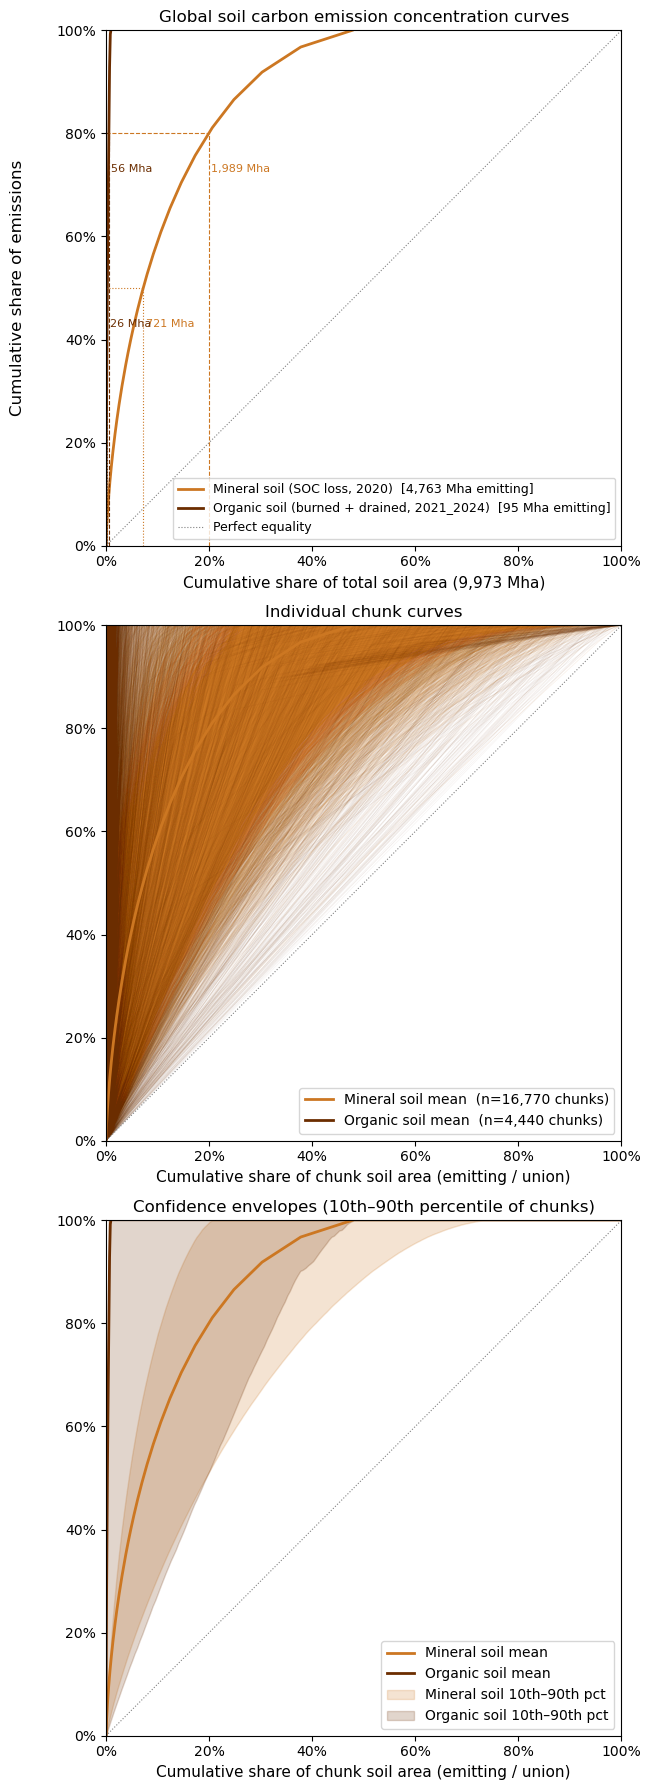

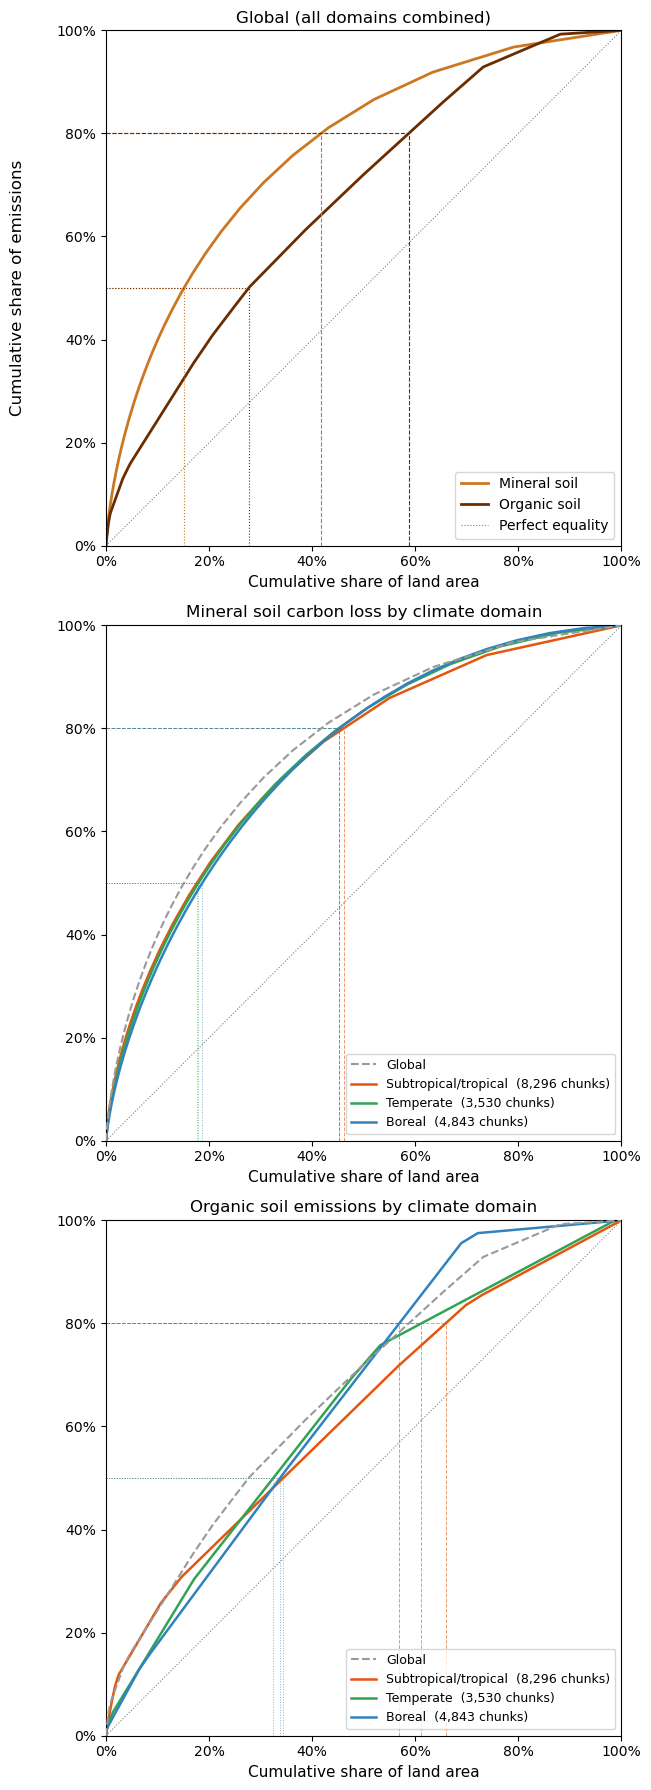

Chunks OK:          16,796
Chunks only NoData: 2,036  (expected — ice/ocean/remote islands)
Chunks missing:     0  (errors)
26 minsoil-skipped  12,356 orgsoil-skipped
Total union soil area: 9,973.3 Mha  (mineral extent ∪ organic)
MS loss area:          4,763.5 Mha  (47.8% of union)
OS emitting area:      94.5 Mha  (0.9% of union)
Flux:    minsoil=6.75457 GtCO2e/yr  orgsoil=2.68846 GtCO2e/yr
Gini:    minsoil=0.5350  orgsoil=0.3442

  Mineral soil 50%: 720.7 Mha (7.2% of total soil area)
  Mineral soil 80%: 1,988.6 Mha (19.9% of total soil area)
  Organic soil 50%: 26.2 Mha (0.3% of total soil area)
  Organic soil 80%: 55.5 Mha (0.6% of total soil area)

Domain                           MS area (Mha)   MS flux (Gt/yr)   OS area (Mha)   OS flux (Gt/yr)
──────────────────────────────────────────────────────────────────────────────────────────────────
Subtropical/tropical                   3,137.0           3.12579            27.2           1.26277
Temperate                              1,0

In [8]:
### Makes figures and validation tables — soil carbon emission concentration curves
### Mineral soil: SOC net change > 0 (carbon loss), 2020
### Organic soil: burned + drained, summed, 2021–2024

MINSOIL_COLOR = '#cc7722'
ORGSOIL_COLOR = '#6b2d00'
DOMAINS_PLOT  = [d for d in DOMAINS if d != 'Unassigned']


def lorenz_from_histogram(bin_area, bin_flux, total_area_ha=None):
    """total_area_ha: x-axis denominator. None = self-normalize (x → 1)."""
    occupied = (bin_area > 0) | (bin_flux > 0)
    if not occupied.any():
        return None, None
    cum_area = np.concatenate([[0.0], np.cumsum(bin_area[occupied][::-1])])
    cum_flux = np.concatenate([[0.0], np.cumsum(bin_flux[occupied][::-1])])
    if cum_area[-1] == 0 or cum_flux[-1] == 0:
        return None, None
    x_denom = total_area_ha if total_area_ha is not None else cum_area[-1]
    return cum_area / x_denom, cum_flux / cum_flux[-1]

def gini(x, y):
    return 2.0 * np.trapezoid(y, x) - 1.0

total_union_area_Mha = total_union_area_ha / 1e6

# Global curves normalized by union area: MS ends at ms_area/union, OS ends at os_area/union
ms_x, ms_y = lorenz_from_histogram(minsoil_bin_area, minsoil_bin_flux, total_union_area_ha)
os_x, os_y = lorenz_from_histogram(orgsoil_bin_area, orgsoil_bin_flux, total_union_area_ha)

# Self-normalized global curves: used for Figure 2 (domain comparison) and Gini
ms_xs, ms_ys = lorenz_from_histogram(minsoil_bin_area, minsoil_bin_flux)
os_xs, os_ys = lorenz_from_histogram(orgsoil_bin_area, orgsoil_bin_flux)

ms_area_Mha = minsoil_bin_area.sum() / 1e6
os_area_Mha = orgsoil_bin_area.sum() / 1e6
ms_flux_Gt  = minsoil_bin_flux.sum() / 1e9
os_flux_Gt  = orgsoil_bin_flux.sum() / 1e9
area_label  = f"Global_minsoil{MINSOIL_PERIOD}_orgsoil{ORGSOIL_PERIOD}"

# Domain curves: self-normalized within each domain's own emitting area
domain_curves = {}
for d in DOMAINS:
    mx, my = lorenz_from_histogram(domain_minsoil_bin_area[d], domain_minsoil_bin_flux[d])
    ox, oy = lorenz_from_histogram(domain_orgsoil_bin_area[d], domain_orgsoil_bin_flux[d])
    if mx is not None or ox is not None:
        domain_curves[d] = {
            'ms_x': mx, 'ms_y': my, 'os_x': ox, 'os_y': oy,
            'ms_area_Mha': domain_minsoil_bin_area[d].sum() / 1e6,
            'os_area_Mha': domain_orgsoil_bin_area[d].sum() / 1e6,
            'ms_flux_Gt' : domain_minsoil_bin_flux[d].sum() / 1e9,
            'os_flux_Gt' : domain_orgsoil_bin_flux[d].sum() / 1e9,
        }

pct_fmt = plt.FuncFormatter(lambda v, _: f'{100*v:.0f}%')
x_c     = np.linspace(0, 1, N_PLOT_POINTS)


def _ref_lines(ax, x_curve, y_curve, color, total_area_Mha=None):
    """50%/80% reference lines. Annotates with Mha when total_area_Mha is provided."""
    if x_curve is None:
        return
    for target, ls in [(0.80, '--'), (0.50, ':')]:
        x_at = np.interp(target, y_curve, x_curve)
        ax.axvline(x=x_at, ymin=0, ymax=target, color=color, lw=0.8, ls=ls)
        ax.axhline(y=target, xmin=0, xmax=x_at,  color=color, lw=0.8, ls=ls)
        if total_area_Mha is not None:
            mha = x_at * total_area_Mha
            ax.text(x_at + 0.005, target - 0.06, f'{mha:,.0f} Mha',
                    color=color, fontsize=8, ha='left', va='top')

def _ref_lines_domain(ax, x_curve, y_curve, color):
    if x_curve is None:
        return
    for target, ls in [(0.80, '--'), (0.50, ':')]:
        x_at = np.interp(target, y_curve, x_curve)
        ax.axvline(x=x_at, ymin=0, ymax=target, color=color, lw=0.7, ls=ls, alpha=0.6)
        ax.axhline(y=target, xmin=0, xmax=x_at,  color=color, lw=0.7, ls=ls, alpha=0.6)


# ── Figure 1: Global curves (3 panels) ────────────────────────────────────
fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 18))

# Panel 1 — global comparison: x = fraction of total union soil area
ax1.plot(ms_x, ms_y, color=MINSOIL_COLOR, lw=2,
         label=f'Mineral soil (SOC loss, {MINSOIL_PERIOD})  [{ms_area_Mha:,.0f} Mha emitting]')
ax1.plot(os_x, os_y, color=ORGSOIL_COLOR, lw=2,
         label=f'Organic soil (burned + drained, {ORGSOIL_PERIOD})  [{os_area_Mha:,.0f} Mha emitting]')
ax1.plot([0,1],[0,1], color='gray', lw=0.8, ls=':', label='Perfect equality')
_ref_lines(ax1, ms_x, ms_y, MINSOIL_COLOR, total_area_Mha=total_union_area_Mha)
_ref_lines(ax1, os_x, os_y, ORGSOIL_COLOR, total_area_Mha=total_union_area_Mha)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.set_box_aspect(1)
ax1.set_xlabel(f'Cumulative share of total soil area ({total_union_area_Mha:,.0f} Mha)', fontsize=11)
ax1.set_title('Global soil carbon emission concentration curves', fontsize=12)
ax1.legend(loc='lower right', fontsize=9)
ax1.xaxis.set_major_formatter(pct_fmt); ax1.yaxis.set_major_formatter(pct_fmt)

# Panel 2 — individual chunk curves + global mean
# Chunk curves are normalized by each chunk's own union area (x ends at emitting/union ≤ 1)
# Global mean lines use the same union-area normalization for consistency
if chunk_minsoil_curves:
    ax2.add_collection(LineCollection(
        [np.column_stack(c) for c in chunk_minsoil_curves],
        colors=MINSOIL_COLOR, alpha=INDIVIDUAL_ALPHA, lw=0.5, zorder=1))
if chunk_orgsoil_curves:
    ax2.add_collection(LineCollection(
        [np.column_stack(c) for c in chunk_orgsoil_curves],
        colors=ORGSOIL_COLOR, alpha=INDIVIDUAL_ALPHA, lw=0.5, zorder=1))
ax2.plot(ms_x, ms_y, color=MINSOIL_COLOR, lw=2, zorder=2,
         label=f'Mineral soil mean  (n={len(chunk_minsoil_curves):,} chunks)')
ax2.plot(os_x, os_y, color=ORGSOIL_COLOR, lw=2, zorder=2,
         label=f'Organic soil mean  (n={len(chunk_orgsoil_curves):,} chunks)')
ax2.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
ax2.set_xlim(0,1); ax2.set_ylim(0,1); ax2.set_box_aspect(1)
ax2.set_xlabel('Cumulative share of chunk soil area (emitting / union)', fontsize=11)
ax2.set_title('Individual chunk curves', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.xaxis.set_major_formatter(pct_fmt); ax2.yaxis.set_major_formatter(pct_fmt)

# Panel 3 — percentile envelopes
ax3.plot(ms_x, ms_y, color=MINSOIL_COLOR, lw=2, label='Mineral soil mean')
ax3.plot(os_x, os_y, color=ORGSOIL_COLOR, lw=2, label='Organic soil mean')
ax3.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
if len(chunk_minsoil_curves) >= 10:
    msmat = np.vstack([np.interp(x_c, cx, cy, right=1.0) for cx, cy in chunk_minsoil_curves])
    ax3.fill_between(x_c, np.percentile(msmat, 10, axis=0),
                     np.percentile(msmat, 90, axis=0),
                     color=MINSOIL_COLOR, alpha=0.2, label='Mineral soil 10th–90th pct')
if len(chunk_orgsoil_curves) >= 10:
    osmat = np.vstack([np.interp(x_c, cx, cy, right=1.0) for cx, cy in chunk_orgsoil_curves])
    ax3.fill_between(x_c, np.percentile(osmat, 10, axis=0),
                     np.percentile(osmat, 90, axis=0),
                     color=ORGSOIL_COLOR, alpha=0.2, label='Organic soil 10th–90th pct')
ax3.set_xlim(0,1); ax3.set_ylim(0,1); ax3.set_box_aspect(1)
ax3.set_xlabel('Cumulative share of chunk soil area (emitting / union)', fontsize=11)
ax3.set_title('Confidence envelopes (10th–90th percentile of chunks)', fontsize=12)
ax3.legend(loc='lower right', fontsize=10)
ax3.xaxis.set_major_formatter(pct_fmt); ax3.yaxis.set_major_formatter(pct_fmt)

plt.tight_layout()
pos1 = ax1.get_position()
fig1.text(pos1.x0 - 0.12, (pos1.y0 + pos1.y1) / 2,
          'Cumulative share of emissions', fontsize=12, va='center', rotation='vertical')
# fig1.savefig("/mnt/c/GIS/AFOLU_flux_model/LULUCF/soil_accum_curves/20260710/fig1_global.png",
#              dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2: Climate domain breakdown (3 panels) ─────────────────────────
# Uses self-normalized curves (ms_xs, ms_ys, os_xs, os_ys) so all domain curves
# share the same 0–100% x-axis and are directly comparable with each other.
fig2, (ax_top, ax_mid, ax_bot) = plt.subplots(3, 1, figsize=(8, 18))

# Panel 1 — global reference (self-normalized)
ax_top.plot(ms_xs, ms_ys, color=MINSOIL_COLOR, lw=2, label='Mineral soil')
ax_top.plot(os_xs, os_ys, color=ORGSOIL_COLOR, lw=2, label='Organic soil')
ax_top.plot([0,1],[0,1], color='gray', lw=0.8, ls=':', label='Perfect equality')
_ref_lines(ax_top, ms_xs, ms_ys, MINSOIL_COLOR)
_ref_lines(ax_top, os_xs, os_ys, ORGSOIL_COLOR)
ax_top.set_xlim(0,1); ax_top.set_ylim(0,1); ax_top.set_box_aspect(1)
ax_top.set_xlabel('Cumulative share of land area', fontsize=11)
ax_top.set_title('Global (all domains combined)', fontsize=12)
ax_top.legend(loc='lower right', fontsize=10)
ax_top.xaxis.set_major_formatter(pct_fmt); ax_top.yaxis.set_major_formatter(pct_fmt)

# Panel 2 — mineral soil by domain
ax_mid.plot(ms_xs, ms_ys, color='#999999', lw=1.5, ls='--', label='Global', zorder=10)
ax_mid.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
for d in DOMAINS_PLOT:
    if d in domain_curves and domain_curves[d]['ms_x'] is not None:
        dc  = domain_curves[d]
        col = DOMAIN_COLORS[d]
        ax_mid.plot(dc['ms_x'], dc['ms_y'], color=col, lw=1.8,
                    label=f"{d}  ({n_ok_domain[d]:,} chunks)")
        _ref_lines_domain(ax_mid, dc['ms_x'], dc['ms_y'], col)
ax_mid.set_xlim(0,1); ax_mid.set_ylim(0,1); ax_mid.set_box_aspect(1)
ax_mid.set_xlabel('Cumulative share of land area', fontsize=11)
ax_mid.set_title('Mineral soil carbon loss by climate domain', fontsize=12)
ax_mid.legend(loc='lower right', fontsize=9)
ax_mid.xaxis.set_major_formatter(pct_fmt); ax_mid.yaxis.set_major_formatter(pct_fmt)

# Panel 3 — organic soil by domain
ax_bot.plot(os_xs, os_ys, color='#999999', lw=1.5, ls='--', label='Global', zorder=10)
ax_bot.plot([0,1],[0,1], color='gray', lw=0.8, ls=':')
for d in DOMAINS_PLOT:
    if d in domain_curves and domain_curves[d]['os_x'] is not None:
        dc  = domain_curves[d]
        col = DOMAIN_COLORS[d]
        ax_bot.plot(dc['os_x'], dc['os_y'], color=col, lw=1.8,
                    label=f"{d}  ({n_ok_domain[d]:,} chunks)")
        _ref_lines_domain(ax_bot, dc['os_x'], dc['os_y'], col)
ax_bot.set_xlim(0,1); ax_bot.set_ylim(0,1); ax_bot.set_box_aspect(1)
ax_bot.set_xlabel('Cumulative share of land area', fontsize=11)
ax_bot.set_title('Organic soil emissions by climate domain', fontsize=12)
ax_bot.legend(loc='lower right', fontsize=9)
ax_bot.xaxis.set_major_formatter(pct_fmt); ax_bot.yaxis.set_major_formatter(pct_fmt)

plt.tight_layout()
pos_top = ax_top.get_position()
fig2.text(pos_top.x0 - 0.12, (pos_top.y0 + pos_top.y1) / 2,
          'Cumulative share of emissions', fontsize=12, va='center', rotation='vertical')
# fig2.savefig("/mnt/c/GIS/AFOLU_flux_model/LULUCF/soil_accum_curves/20260710/fig2_by_domain.png",
#              dpi=150, bbox_inches='tight')
plt.show()


# ── Validation ─────────────────────────────────────────────────────────────
print(f"Chunks OK:          {n_ok:,}")
print(f"Chunks only NoData: {n_no_data:,}  (expected — ice/ocean/remote islands)")
print(f"Chunks missing:     {n_missing:,}  (errors)")
print(f"{n_skipped_minsoil:,} minsoil-skipped  {n_skipped_orgsoil:,} orgsoil-skipped")
print(f"Total union soil area: {total_union_area_Mha:,.1f} Mha  (mineral extent ∪ organic)")
print(f"MS loss area:          {ms_area_Mha:,.1f} Mha  ({ms_area_Mha/total_union_area_Mha:.1%} of union)")
print(f"OS emitting area:      {os_area_Mha:,.1f} Mha  ({os_area_Mha/total_union_area_Mha:.1%} of union)")
print(f"Flux:    minsoil={ms_flux_Gt:.5f} GtCO2e/yr  orgsoil={os_flux_Gt:.5f} GtCO2e/yr")
print(f"Gini:    minsoil={gini(ms_xs, ms_ys):.4f}  orgsoil={gini(os_xs, os_ys):.4f}")
print()
for label, xc, yc in [('Mineral soil', ms_x, ms_y), ('Organic soil', os_x, os_y)]:
    for frac in [0.5, 0.8]:
        xi  = float(np.interp(frac, yc, xc))
        mha = xi * total_union_area_Mha
        print(f"  {label} {frac:.0%}: {mha:,.1f} Mha ({xi:.1%} of total soil area)")
print()

hdr = (f"{'Domain':<30}  {'MS area (Mha)':>14}  {'MS flux (Gt/yr)':>16}"
       f"  {'OS area (Mha)':>14}  {'OS flux (Gt/yr)':>16}")
print(hdr)
print("─" * len(hdr))
for d in DOMAINS:
    dc = domain_curves.get(d, {})
    print(f"{d:<30}  {dc.get('ms_area_Mha',0):>14,.1f}  {dc.get('ms_flux_Gt',0):>16.5f}"
          f"  {dc.get('os_area_Mha',0):>14,.1f}  {dc.get('os_flux_Gt',0):>16.5f}")
print("─" * len(hdr))
print(f"{'TOTAL':<30}  {ms_area_Mha:>14,.1f}  {ms_flux_Gt:>16.5f}"
      f"  {os_area_Mha:>14,.1f}  {os_flux_Gt:>16.5f}")


# ── CSV output ─────────────────────────────────────────────────────────────
import os, pandas as pd

RUN_DATE = "20260710"
OUT_DIR  = f"/mnt/c/GIS/AFOLU_flux_model/LULUCF/soil_accum_curves/{RUN_DATE}"
os.makedirs(OUT_DIR, exist_ok=True)

# Global curves — both on a common union-area x-grid
x_common = np.linspace(0, max(ms_x[-1], os_x[-1]), N_PLOT_POINTS)
pd.DataFrame({
    'cum_area_frac_of_union': x_common,
    'ms_cum_flux_frac': np.interp(x_common, ms_x, ms_y, right=1.0),
    'os_cum_flux_frac': np.interp(x_common, os_x, os_y, right=1.0),
    'total_union_area_Mha': total_union_area_Mha,
}).to_csv(f"{OUT_DIR}/soil_lorenz_global.csv", index=False)

# Domain curves
rows = []
for d in DOMAINS:
    dc = domain_curves.get(d)
    if dc is None:
        continue
    x_ref = dc['ms_x'] if dc['ms_x'] is not None else dc['os_x']
    for i, xi in enumerate(x_ref):
        rows.append({
            'domain':           d,
            'cum_area_frac':    xi,
            'ms_cum_flux_frac': dc['ms_y'][i] if dc['ms_x'] is not None else np.nan,
            'os_cum_flux_frac': float(np.interp(xi, dc['os_x'], dc['os_y']))
                                 if dc['os_x'] is not None else np.nan,
        })
pd.DataFrame(rows).to_csv(f"{OUT_DIR}/soil_lorenz_by_domain.csv", index=False)

# Summary stats
meta_rows = [{
    'scope': 'global', 'domain': 'all',
    'total_union_area_Mha':  total_union_area_Mha,
    'ms_area_Mha':           ms_area_Mha,
    'ms_flux_GtCO2_yr':      ms_flux_Gt,
    'ms_gini':               gini(ms_xs, ms_ys),
    'os_area_Mha':           os_area_Mha,
    'os_flux_GtCO2e_yr':     os_flux_Gt,
    'os_gini':               gini(os_xs, os_ys),
}]
for d in DOMAINS:
    dc = domain_curves.get(d)
    if dc is None:
        continue
    meta_rows.append({
        'scope': 'domain', 'domain': d,
        'total_union_area_Mha':  domain_union_area_ha.get(d, 0.0) / 1e6,
        'ms_area_Mha':           dc['ms_area_Mha'],
        'ms_flux_GtCO2_yr':      dc['ms_flux_Gt'],
        'ms_gini':               gini(dc['ms_x'], dc['ms_y']) if dc['ms_x'] is not None else np.nan,
        'os_area_Mha':           dc['os_area_Mha'],
        'os_flux_GtCO2e_yr':     dc['os_flux_Gt'],
        'os_gini':               gini(dc['os_x'], dc['os_y']) if dc['os_x'] is not None else np.nan,
    })
pd.DataFrame(meta_rows).to_csv(f"{OUT_DIR}/soil_lorenz_summary.csv", index=False)

print(f"\nCSVs written to {OUT_DIR}")